# Taller Abandono de producto financiero

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## 1. Estructura de los datos

In [2]:
df_raw = pd.read_csv("abandono_producto_financiero.csv", encoding="utf-8")
df_raw.head()

,numero_fila,id_cliente,apellido,puntaje_crediticio,pais,sexo,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
0,1,15634602,Hargrave,619,Francia,Mujer,42,2,0.0000,1,1,1,"101,348.8800",1
1,2,15647311,Hill,608,España,Mujer,41,1,"83,807.8600",1,0,1,"112,542.5800",0
2,3,15619304,Onio,502,Francia,Mujer,42,8,"159,660.8000",3,1,0,"113,931.5700",1
3,4,15701354,Boni,699,Francia,Mujer,39,1,0.0000,2,0,0,"93,826.6300",0
4,5,15737888,Mitchell,850,España,Mujer,43,2,"125,510.8200",1,1,1,"79,084.1000",0


In [3]:
print("Columnas:", list(df_raw.columns))
print("Dimensión (filas, columnas):", df_raw.shape)
df_raw.dtypes

Columnas: ['numero_fila', 'id_cliente', 'apellido', 'puntaje_crediticio', 'pais', 'sexo', 'edad', 'antiguedad', 'saldo', 'numero_productos', 'tiene_tarjeta', 'miembro_activo', 'salario_estimado', 'abandono']
Dimensión (filas, columnas): (10000, 14)


numero_fila             int64
id_cliente              int64
apellido                  str
puntaje_crediticio      int64
pais                      str
sexo                      str
edad                    int64
antiguedad              int64
saldo                 float64
numero_productos        int64
tiene_tarjeta           int64
miembro_activo          int64
salario_estimado      float64
abandono                int64
dtype: object

In [4]:
df_raw.describe()

,numero_fila,id_cliente,puntaje_crediticio,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
count,"10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000"
mean,"5,000.5000","15,690,940.5694",650.5288,38.9218,5.0128,"76,485.8893",1.5302,0.7055,0.5151,"100,090.2399",0.2037
std,"2,886.8957","71,936.1861",96.6533,10.4878,2.8922,"62,397.4052",0.5817,0.4558,0.4998,"57,510.4928",0.4028
min,1.0000,"15,565,701.0000",350.0000,18.0000,0.0000,0.0000,1.0000,0.0000,0.0000,11.5800,0.0000
25%,"2,500.7500","15,628,528.2500",584.0000,32.0000,3.0000,0.0000,1.0000,0.0000,0.0000,"51,002.1100",0.0000
50%,"5,000.5000","15,690,738.0000",652.0000,37.0000,5.0000,"97,198.5400",1.0000,1.0000,1.0000,"100,193.9150",0.0000
75%,"7,500.2500","15,753,233.7500",718.0000,44.0000,7.0000,"127,644.2400",2.0000,1.0000,1.0000,"149,388.2475",0.0000
max,"10,000.0000","15,815,690.0000",850.0000,92.0000,10.0000,"250,898.0900",4.0000,1.0000,1.0000,"199,992.4800",1.0000


In [5]:
df = df_raw.drop(columns=["numero_fila", "id_cliente", "apellido"]).copy()

df["pais"] = pd.Categorical(df["pais"], categories=["Francia", "Alemania", "España"])
df["sexo"] = pd.Categorical(df["sexo"], categories=["Mujer", "Hombre"])
df["abandono"] = df["abandono"].astype(int)

print("Dimensión para el modelo:", df.shape)
print("Datos faltantes:", df.isna().sum().sum())
df.dtypes

Dimensión para el modelo: (10000, 11)
Datos faltantes: 0


puntaje_crediticio       int64
pais                  category
sexo                  category
edad                     int64
antiguedad               int64
saldo                  float64
numero_productos         int64
tiene_tarjeta            int64
miembro_activo           int64
salario_estimado       float64
abandono                 int64
dtype: object

**1. ¿Cuántas variables tiene la base cruda? ¿Cuántas quedan para el modelo?**
La base cruda tiene **14 variables** y 10.000 filas. Al eliminar los identificadores (`numero_fila`, `id_cliente`, `apellido`) quedan **11 variables**: 10 explicativas y la respuesta `abandono`.

**2. ¿Cuántas son cuantitativas?**
**6**: `puntaje_crediticio`, `edad`, `antiguedad`, `saldo`, `numero_productos` (entero) y `salario_estimado`.

**3. ¿Cuántas son categóricas o binarias (incluyendo abandono)?**
**5**: dos categóricas (`pais`, `sexo`) y tres binarias 0/1 (`tiene_tarjeta`, `miembro_activo` y la respuesta `abandono`).

**4. ¿Qué implica esta mezcla para el logit en Python?**
Las numéricas y las binarias 0/1 entran directo en la fórmula. Las categóricas de texto necesitan dummies: con `C(pais)` y `C(sexo)`, `statsmodels` (vía patsy) crea automáticamente $k-1$ dummies por variable y omite la categoría de referencia (la primera de la lista: Francia y Mujer), lo que evita la trampa de las variables ficticias (colinealidad perfecta con el intercepto). Hacer las dummies a mano obliga a crear y excluir columnas manualmente, con riesgo de error; con `C(·)` y los niveles fijados como `category`, las referencias quedan controladas y los coeficientes se leen como "diferencia frente a Francia / frente a Mujer".

## 2. Descriptivo univariado

In [6]:
conteo = df["abandono"].value_counts().sort_index()
prop = df["abandono"].value_counts(normalize=True).sort_index()
tabla_y = pd.DataFrame({"conteo": conteo, "proporcion": prop})
tabla_y

,conteo,proporcion
abandono,,
0,7963,0.7963
1,2037,0.2037


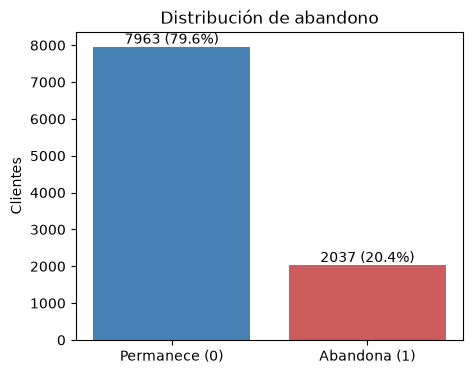

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Permanece (0)", "Abandona (1)"], conteo.values, color=["steelblue", "indianred"])
for i, v in enumerate(conteo.values):
    ax.text(i, v + 80, f"{v} ({prop.values[i]:.1%})", ha="center")
ax.set_ylabel("Clientes")
ax.set_title("Distribución de abandono")
plt.show()

In [8]:
num_vars = ["edad", "puntaje_crediticio", "saldo", "salario_estimado"]
df[num_vars].describe()

,edad,puntaje_crediticio,saldo,salario_estimado
count,"10,000.0000","10,000.0000","10,000.0000","10,000.0000"
mean,38.9218,650.5288,"76,485.8893","100,090.2399"
std,10.4878,96.6533,"62,397.4052","57,510.4928"
min,18.0000,350.0000,0.0000,11.5800
25%,32.0000,584.0000,0.0000,"51,002.1100"
50%,37.0000,652.0000,"97,198.5400","100,193.9150"
75%,44.0000,718.0000,"127,644.2400","149,388.2475"
max,92.0000,850.0000,"250,898.0900","199,992.4800"


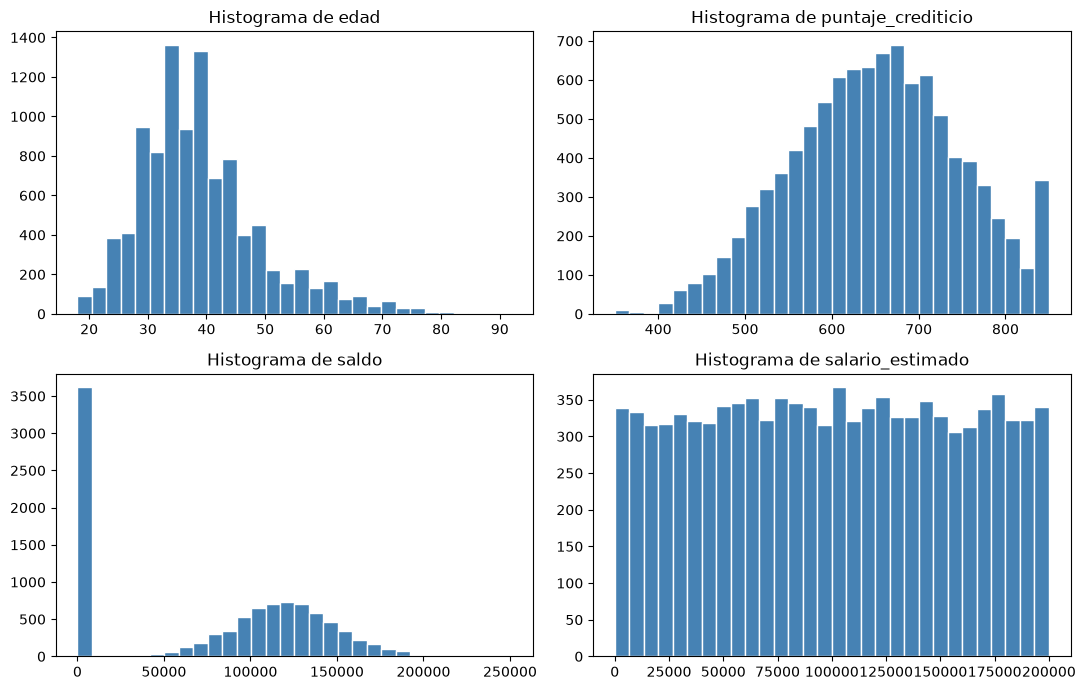

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, v in zip(axes.ravel(), num_vars):
    ax.hist(df[v], bins=30, color="steelblue", edgecolor="white")
    ax.set_title(f"Histograma de {v}")
plt.tight_layout()
plt.show()

In [10]:
for v in ["pais", "sexo", "numero_productos", "miembro_activo"]:
    t = pd.DataFrame({"conteo": df[v].value_counts().sort_index(),
                      "proporcion": df[v].value_counts(normalize=True).sort_index()})
    print(f"\n--- {v} ---")
    print(t)


--- pais ---
          conteo  proporcion
pais                        
Francia     5014      0.5014
Alemania    2509      0.2509
España      2477      0.2477

--- sexo ---
        conteo  proporcion
sexo                      
Mujer     4543      0.4543
Hombre    5457      0.5457

--- numero_productos ---
                  conteo  proporcion
numero_productos                    
1                   5084      0.5084
2                   4590      0.4590
3                    266      0.0266
4                     60      0.0060

--- miembro_activo ---
                conteo  proporcion
miembro_activo                    
0                 4849      0.4849
1                 5151      0.5151


**5. ¿Qué porcentaje de la base abandonó? ¿Por qué un clasificador que siempre diga «permanece» ya parece bueno si uno solo mira la accuracy?**
Abandonó el **20,37 %** de los clientes (2.037 de 10.000); el 79,63 % permanece. Las clases están desbalanceadas: un clasificador trivial que siempre prediga «permanece» acierta en el 79,63 % de los casos, así que su exactitud ya es cercana al 80 % sin haber aprendido nada. Pero su sensibilidad es 0: no detecta a ninguno de los clientes que se van, que son justamente los que le interesan al área de retención. Por eso la exactitud debe leerse junto con la sensibilidad y la especificidad.

Otros rasgos del univariado: el saldo tiene una gran masa en 0 (≈36 % de los clientes), la edad es sesgada a la derecha (mediana 37, rango 18–92), Francia concentra cerca de la mitad de la base y casi todos los clientes tienen 1 o 2 productos.

## 3. Bivariado con la respuesta

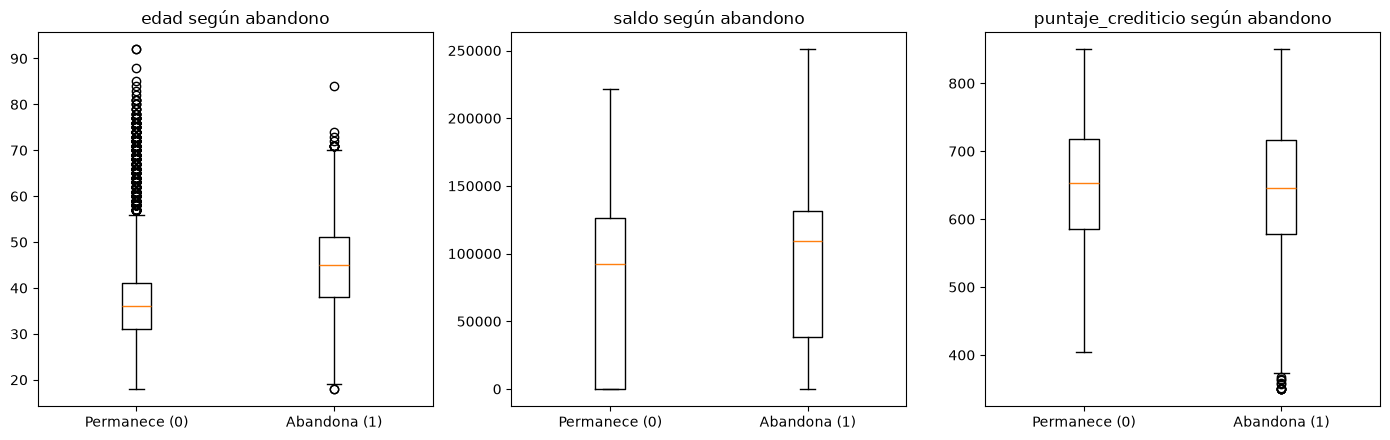

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, v in zip(axes, ["edad", "saldo", "puntaje_crediticio"]):
    datos = [df.loc[df["abandono"] == 0, v], df.loc[df["abandono"] == 1, v]]
    ax.boxplot(datos, tick_labels=["Permanece (0)", "Abandona (1)"])
    ax.set_title(f"{v} según abandono")
plt.tight_layout()
plt.show()

In [12]:
df.groupby("abandono")[["edad", "saldo", "puntaje_crediticio"]].agg(["median", "mean"])

edad                saldo             puntaje_crediticio         
          median    mean       median        mean             median     mean
abandono                                                                     
0        36.0000 37.4084  92,072.6800 72,745.2968           653.0000 651.8532
1        45.0000 44.8380 109,349.2900 91,108.5393           646.0000 645.3515

In [13]:
resultados_chi = []
for v in ["miembro_activo", "numero_productos", "pais"]:
    tabla = pd.crosstab(df[v], df["abandono"])
    tasa = pd.crosstab(df[v], df["abandono"], normalize="index")
    chi2, p, gl, _ = chi2_contingency(tabla)
    resultados_chi.append({"variable": v, "chi2": chi2, "gl": gl, "p_valor": p})
    print(f"\n===== {v} =====")
    print(tabla)
    print("Tasa por fila:")
    print(tasa.round(3))
    print(f"Ji-cuadrado = {chi2:.2f}, gl = {gl}, p = {p:.3g}")

pd.DataFrame(resultados_chi)


===== miembro_activo =====
abandono           0     1
miembro_activo            
0               3547  1302
1               4416   735
Tasa por fila:
abandono            0      1
miembro_activo              
0              0.7310 0.2690
1              0.8570 0.1430
Ji-cuadrado = 242.99, gl = 1, p = 8.79e-55

===== numero_productos =====
abandono             0     1
numero_productos            
1                 3675  1409
2                 4242   348
3                   46   220
4                    0    60
Tasa por fila:
abandono              0      1
numero_productos              
1                0.7230 0.2770
2                0.9240 0.0760
3                0.1730 0.8270
4                0.0000 1.0000
Ji-cuadrado = 1503.63, gl = 3, p = 0

===== pais =====
abandono     0    1
pais               
Francia   4204  810
Alemania  1695  814
España    2064  413
Tasa por fila:
abandono      0      1
pais                  
Francia  0.8380 0.1620
Alemania 0.6760 0.3240
España   0.8330 0.1670


,variable,chi2,gl,p_valor
0,miembro_activo,242.9853,1,0.0000
1,numero_productos,"1,503.6294",3,0.0000
2,pais,301.2553,2,0.0000


**6. Distribución de edad entre quien abandona y quien permanece.**
Es la diferencia más visible de los boxplots. Quienes abandonan son claramente mayores: **mediana de 45 años** frente a **36 años** en quienes permanecen (medias 44,8 vs 37,4). La caja de los que abandonan está desplazada hacia arriba, y en el grupo que permanece las edades altas aparecen como atípicos. La edad se asocia con más abandono.

**7. Saldo y puntaje crediticio entre los dos grupos.**
*Saldo:* quienes abandonan tienen mayor saldo (mediana ≈ 109.349 frente a ≈ 92.073). Parte de la diferencia viene de la masa de clientes con saldo 0, que se concentra en quienes permanecen. Se van clientes con dinero en la cuenta, lo que hace más costosa la pérdida.
*Puntaje crediticio:* prácticamente no hay diferencia (mediana 646 vs 653; medias 645 vs 652); las cajas casi se superponen. A simple vista no discrimina entre grupos.

**8. ¿Los clientes activos presentan menor abandono?**
Sí. Entre los inactivos abandona el **26,9 %**; entre los activos, el **14,3 %** (casi la mitad). El ji-cuadrado (≈ 243, gl = 1, p ≈ 9×10⁻⁵⁵) rechaza la independencia: estar activo se asocia con menos abandono.

**9. ¿Más productos se asocia siempre con menos abandono?**
**No.** La relación no es monótona: con 1 producto abandona el 27,7 %, con 2 baja al **7,6 %**, pero con 3 sube al **82,7 %** y con 4 abandona el **100 %** (grupos pequeños). El ji-cuadrado es el más alto (≈ 1.504, gl = 3, p ≈ 0). Dos productos es el "punto dulce"; más allá aparece un grupo de altísimo riesgo. Esto importa para el logit: con `numero_productos` como continua, un solo coeficiente no captura esta forma en U.

**10. ¿Qué variable parece tener mayor relación con el abandono?**
Entre las categóricas, **`numero_productos`** tiene la asociación más fuerte (χ² ≈ 1.504, muy por encima de `pais` ≈ 301 y `miembro_activo` ≈ 243), con tasas de abandono que van del 7,6 % al 100 %. Entre las continuas, **`edad`** muestra la separación más clara: 9 años de diferencia en la mediana, frente a diferencias mínimas en puntaje. En conjunto, `numero_productos` y `edad` son las de mayor relación; les siguen `pais` (Alemania 32,4 % frente a ~16 % en Francia y España) y `miembro_activo`.

## 4. De la recta al logit

In [14]:
ols_edad = smf.ols("abandono ~ edad", data=df).fit()
print(ols_edad.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2228      0.015    -15.014      0.000      -0.252      -0.194
edad           0.0110      0.000     29.767      0.000       0.010       0.012


In [15]:
logit_edad = smf.logit("abandono ~ edad", data=df).fit()
print(logit_edad.summary())

Optimization terminated successfully.
         Current function value: 0.467553
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               abandono   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.07505
Time:                        17:49:18   Log-Likelihood:                -4675.5
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                5.077e-167
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.9286      0.103    -38.096      0.000      -4.131      -3.726
edad           0.0629      0.

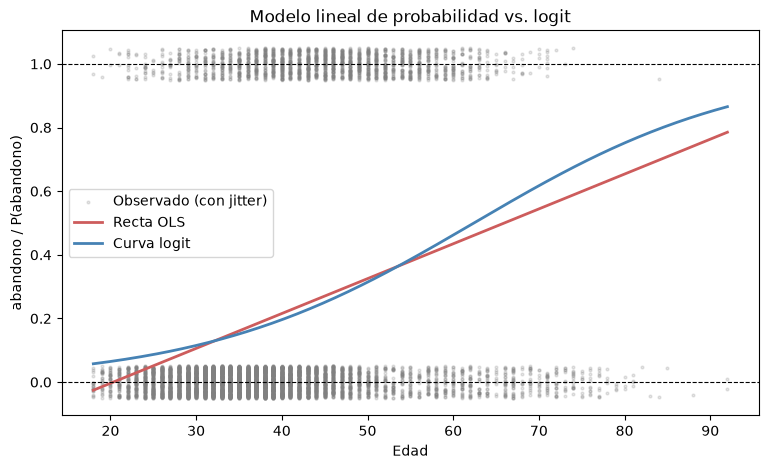

Predicción OLS en edad mínima y máxima:
0   -0.0255
1    0.7853
dtype: float64


In [16]:
rng_plot = np.random.default_rng(1)
jitter = rng_plot.uniform(-0.05, 0.05, size=len(df))

malla = pd.DataFrame({"edad": np.linspace(df["edad"].min(), df["edad"].max(), 200)})
malla["ols"] = ols_edad.predict(malla)
malla["logit"] = logit_edad.predict(malla)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df["edad"], df["abandono"] + jitter, s=4, alpha=0.2, color="gray", label="Observado (con jitter)")
ax.plot(malla["edad"], malla["ols"], color="indianred", lw=2, label="Recta OLS")
ax.plot(malla["edad"], malla["logit"], color="steelblue", lw=2, label="Curva logit")
ax.axhline(0, ls="--", color="black", lw=0.8)
ax.axhline(1, ls="--", color="black", lw=0.8)
ax.set_xlabel("Edad")
ax.set_ylabel("abandono / P(abandono)")
ax.set_title("Modelo lineal de probabilidad vs. logit")
ax.legend()
plt.show()

print("Predicción OLS en edad mínima y máxima:")
print(ols_edad.predict(pd.DataFrame({"edad": [df['edad'].min(), df['edad'].max()]})))

In [17]:
b0, b1 = logit_edad.params["Intercept"], logit_edad.params["edad"]
or_edad = np.exp(b1)
p40 = logit_edad.predict(pd.DataFrame({"edad": [40]}))[0]
print(f"Intercepto = {b0:.4f}")
print(f"Coeficiente de edad = {b1:.4f}")
print(f"Odds ratio de edad = {or_edad:.4f}")
print(f"P(abandono | edad = 40) = {p40:.4f}")

Intercepto = -3.9286
Coeficiente de edad = 0.0629
Odds ratio de edad = 1.0650
P(abandono | edad = 40) = 0.1961


**11. ¿Por qué la recta de mínimos cuadrados no puede leerse como una probabilidad?**
Porque el modelo lineal de probabilidad no está acotado: la recta crece indefinidamente con la edad y puede salir del intervalo [0, 1]. En esta corrida la recta OLS predice un valor **negativo (≈ −0,026) para un cliente de 18 años**, lo cual no tiene sentido como probabilidad. Además supone que un año más de edad cambia la probabilidad siempre en la misma cantidad (≈ 0,011), sin importar el nivel de partida, y sus errores son heterocedásticos por construcción al ser $y$ binaria. El logit, en cambio, pasa $x\beta$ por la función logística $\Lambda(\cdot)$, cuyo resultado siempre está en (0, 1) y tiene forma de S.

**12. Intercepto, coeficiente de edad y odds ratio del logit simple.**
- Intercepto: **−3,9286**
- Coeficiente de edad: **0,0629** (log-odds por año)
- Odds ratio: $e^{0,0629}$ = **1,0650**

*Lectura de negocio:* cada año adicional de edad del cliente aumenta en aproximadamente un **6,5 % los odds de que abandone el banco**; la edad actúa como factor de riesgo. Por ejemplo, 10 años más multiplican los odds por $1,065^{10} ≈ 1,88$.

**13. ¿Qué P(abandono) se obtiene para un cliente de 40 años?**
$P = \Lambda(-3,9286 + 0,0629 \times 40)$ ≈ **0,196**, es decir, cerca del **19,6 %**, muy parecida a la tasa media de la cartera (40 años está cerca de la edad promedio, 38,9).

## 5. Varios modelos y odds ratios

In [18]:
rng = np.random.default_rng(8)
n = len(df)
idx_train = rng.choice(n, size=int(0.7 * n), replace=False)

Train_Data = df.iloc[idx_train].copy()
Test_Data = df.drop(df.index[idx_train]).copy()

print("Filas train:", len(Train_Data), "| Filas test:", len(Test_Data))
print(f"Tasa de abandono - base completa: {df['abandono'].mean():.4f}")
print(f"Tasa de abandono - train:         {Train_Data['abandono'].mean():.4f}")
print(f"Tasa de abandono - test:          {Test_Data['abandono'].mean():.4f}")

Filas train: 7000 | Filas test: 3000
Tasa de abandono - base completa: 0.2037
Tasa de abandono - train:         0.2067
Tasa de abandono - test:          0.1967


In [19]:
formulas = {
    "fit1": "abandono ~ edad",
    "fit2": "abandono ~ edad + puntaje_crediticio",
    "fit3": "abandono ~ edad + puntaje_crediticio + C(sexo)",
    "fit4": "abandono ~ edad + puntaje_crediticio + C(sexo) + C(pais)",
    "fit5": "abandono ~ edad + puntaje_crediticio + C(sexo) + C(pais) + saldo + numero_productos + miembro_activo",
    "fit6": "abandono ~ edad + puntaje_crediticio + C(sexo) + C(pais) + saldo + numero_productos + miembro_activo"
            " + antiguedad + tiene_tarjeta + salario_estimado",
}

fits = {k: smf.logit(f, data=Train_Data).fit(disp=0) for k, f in formulas.items()}

tabla_aic = pd.DataFrame({
    "parametros": [len(m.params) for m in fits.values()],
    "AIC": [m.aic for m in fits.values()],
    "pseudo_R2": [m.prsquared for m in fits.values()],
}, index=fits.keys())
tabla_aic

,parametros,AIC,pseudo_R2
fit1,2,"6,587.9137",0.0771
fit2,3,"6,581.4147",0.0783
fit3,4,"6,497.9951",0.0903
fit4,6,"6,327.7609",0.1147
fit5,9,"6,021.8148",0.1584
fit6,12,"6,020.5700",0.1594


In [20]:
# p-valores de las tres variables que agrega fit6
fits["fit6"].pvalues[["antiguedad", "tiene_tarjeta", "salario_estimado"]]

antiguedad         0.0364
tiene_tarjeta      0.9647
salario_estimado   0.0860
dtype: float64

In [21]:
# Chequeo adicional: fit5 + antiguedad (la única de las tres con p < 0.05)
fit5b = smf.logit(formulas["fit5"] + " + antiguedad", data=Train_Data).fit(disp=0)
print(f"AIC fit5 = {fits['fit5'].aic:.2f} | AIC fit5 + antiguedad = {fit5b.aic:.2f} | AIC fit6 = {fits['fit6'].aic:.2f}")

AIC fit5 = 6021.81 | AIC fit5 + antiguedad = 6019.52 | AIC fit6 = 6020.57


In [22]:
logit_fits = fits["fit5"]   # modelo de trabajo
print(logit_fits.summary())

                           Logit Regression Results                           
Dep. Variable:               abandono   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6991
Method:                           MLE   Df Model:                            8
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                  0.1584
Time:                        17:57:10   Log-Likelihood:                -3001.9
converged:                       True   LL-Null:                       -3567.0
Covariance Type:            nonrobust   LLR p-value:                1.165e-238
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -3.2573      0.277    -11.759      0.000      -3.800      -2.714
C(sexo)[T.Hombre]      -0.5547      0.065     -8.527      0.000      -0.682      -0.427
C(pais)[T.Aleman

In [23]:
or_tabla = pd.DataFrame({
    "coef": logit_fits.params,
    "odds_ratio": np.exp(logit_fits.params),
    "IC95_inf": np.exp(logit_fits.conf_int()[0]),
    "IC95_sup": np.exp(logit_fits.conf_int()[1]),
    "p_valor": logit_fits.pvalues,
})
or_tabla["lectura"] = np.where(or_tabla["odds_ratio"] > 1, "riesgo", "protector")
or_tabla.loc["Intercept", "lectura"] = "-"
or_tabla

,coef,odds_ratio,IC95_inf,IC95_sup,p_valor,lectura
Intercept,-3.2573,0.0385,0.0224,0.0662,0.0000,-
C(sexo)[T.Hombre],-0.5547,0.5743,0.5055,0.6524,0.0000,protector
C(pais)[T.Alemania],0.7907,2.2049,1.8815,2.5838,0.0000,riesgo
C(pais)[T.España],0.0534,1.0548,0.8942,1.2443,0.5266,riesgo
edad,0.0750,1.0779,1.0713,1.0845,0.0000,riesgo
puntaje_crediticio,-0.0009,0.9991,0.9985,0.9998,0.0098,protector
saldo,0.0000,1.0000,1.0000,1.0000,0.0000,riesgo
numero_productos,-0.1908,0.8263,0.7382,0.9248,0.0009,protector
miembro_activo,-1.0923,0.3354,0.2931,0.3839,0.0000,protector


In [24]:
# OR en unidades más legibles
print(f"OR edad (+10 años):              {np.exp(10 * logit_fits.params['edad']):.3f}")
print(f"OR puntaje (+100 puntos):        {np.exp(100 * logit_fits.params['puntaje_crediticio']):.3f}")
print(f"OR saldo (+100.000):             {np.exp(100000 * logit_fits.params['saldo']):.3f}")

OR edad (+10 años):              2.117
OR puntaje (+100 puntos):        0.917
OR saldo (+100.000):             1.295


**14. ¿Cuántas filas quedan en train y en test? ¿Se conserva la tasa de abandono?**
Train: **7.000** filas; test: **3.000** filas. La tasa de abandono se conserva bien: 20,67 % en train, 19,67 % en test y 20,37 % en la base completa. El sorteo aleatorio no desbalanceó las muestras.

**15. ¿Con qué especificación se queda y por qué? ¿`antiguedad`, `tiene_tarjeta` o `salario_estimado` pagan su puesto?**
El AIC cae fuertemente de fit1 (≈ 6.587,9) a fit5 (≈ 6.021,8): cada bloque aporta, sobre todo `C(pais)` y el bloque saldo + productos + actividad (que baja el AIC en ~306 puntos). De fit5 a fit6 el AIC solo baja ≈ 1,2 puntos a cambio de 3 parámetros más, y el pseudo-R² prácticamente no cambia (0,1584 → 0,1594).
Revisando las tres variables:
- `tiene_tarjeta`: p ≈ 0,965, OR ≈ 1,00 → **no paga su puesto** (coincide con el bivariado: 20,8 % vs 20,2 %, χ² no significativo).
- `salario_estimado`: p ≈ 0,086 → **no es significativa** al 5 %.
- `antiguedad`: p ≈ 0,036, es la única marginalmente significativa; agregarla sola a fit5 baja el AIC ≈ 2,3 puntos, una ganancia pequeña.

Me quedo con **fit5** como modelo de trabajo por **parsimonia**: todas sus variables son significativas (salvo la dummy España, que viene con el factor país), y las diferencias de AIC frente a fit6 o fit5 + antigüedad son de 1 a 2 puntos, tamaño que no justifica complicar el modelo.

**16. Factores de riesgo y factores protectores del modelo de trabajo (fit5).**
*Factores de riesgo (OR > 1):*
- **Alemania** (OR ≈ 2,20): un cliente en Alemania tiene más del doble de odds de abandonar que uno en Francia, ceteris paribus. España no difiere significativamente de Francia (OR ≈ 1,05; p ≈ 0,53).
- **Edad** (OR ≈ 1,078 por año; ≈ 2,12 por cada 10 años): los clientes mayores abandonan más.
- **Saldo** (OR ≈ 1,30 por cada 100.000): a mayor saldo, mayor riesgo; se van clientes valiosos.

*Factores protectores (OR < 1):*
- **Miembro activo** (OR ≈ 0,34): ser activo reduce los odds de abandono en cerca de 66 %; es el protector más fuerte.
- **Hombre** (OR ≈ 0,57): frente a una mujer con el mismo perfil, un hombre tiene ~43 % menos odds de abandonar.
- **Número de productos** (OR ≈ 0,83 por producto): en promedio protege, pero con cautela: el bivariado mostró que con 3–4 productos el abandono se dispara, así que este OR promedia una relación no lineal.
- **Puntaje crediticio** (OR ≈ 0,9991 por punto; ≈ 0,92 por 100 puntos): protector débil, significativo pero de efecto pequeño.

## 6. Predicción en test y matriz de confusión

In [25]:
def indicadores(probs, y, umbral):
    pred = np.where(probs > umbral, 1, 0)
    tabla = pd.crosstab(pred, y, rownames=["Predicho"], colnames=["Real"])
    TP = ((pred == 1) & (y == 1)).sum()
    TN = ((pred == 0) & (y == 0)).sum()
    FP = ((pred == 1) & (y == 0)).sum()
    FN = ((pred == 0) & (y == 1)).sum()
    res = {
        "umbral": umbral, "TP": TP, "TN": TN, "FP": FP, "FN": FN,
        "exactitud": (TP + TN) / (TP + TN + FP + FN),
        "sensibilidad": TP / (TP + FN),
        "especificidad": TN / (TN + FP),
    }
    return tabla, res

probs = logit_fits.predict(Test_Data)
y_test = Test_Data["abandono"]

In [26]:
pred = np.where(probs > 0.5, 1, 0)
pd.crosstab(pred, Test_Data["abandono"], rownames=["Predicho"], colnames=["Real"])

Real,0,1
Predicho,,
0,2309,452
1,101,138


In [27]:
tabla_05, res_05 = indicadores(probs, y_test, 0.5)
tabla_04, res_04 = indicadores(probs, y_test, 0.4)

print("Umbral 0.4:")
print(tabla_04)

comparacion = pd.DataFrame([res_05, res_04]).set_index("umbral")
comparacion

Umbral 0.4:
Real         0    1
Predicho           
0         2206  382
1          204  208


,TP,TN,FP,FN,exactitud,sensibilidad,especificidad
umbral,,,,,,,
0.5000,138,2309,101,452,0.8157,0.2339,0.9581
0.4000,208,2206,204,382,0.8047,0.3525,0.9154


In [28]:
# Referencia: clasificador trivial que siempre dice 'permanece'
print(f"Exactitud del clasificador trivial en test: {(y_test == 0).mean():.4f}")

Exactitud del clasificador trivial en test: 0.8033


**17. TP, TN, FP y FN con umbral 0,5.**
A partir de la matriz de test:
- **TP = 138**: el modelo marcó abandono y el cliente efectivamente se fue. Son los casos de riesgo bien detectados, a los que retención habría llegado a tiempo.
- **TN = 2.309**: el modelo dijo que permanecía y el cliente se quedó. Clientes tranquilos que correctamente no se contactan.
- **FP = 101**: el modelo marcó abandono pero el cliente se quedó. Son **contactos innecesarios**: gasto de retención (llamada, oferta) en alguien que no se iba.
- **FN = 452**: el modelo dijo que permanecía pero el cliente se fue. Son **abandonos no vistos**, el error más costoso para retención porque el cliente se pierde sin intervención.

**18. Exactitud, sensibilidad y especificidad. ¿Qué cambia con umbral 0,4?**

| Indicador | Umbral 0,5 | Umbral 0,4 |
|---|---|---|
| TP / FN | 138 / 452 | 208 / 382 |
| TN / FP | 2.309 / 101 | 2.206 / 204 |
| Exactitud | 81,6 % | 80,5 % |
| Sensibilidad | 23,4 % | 35,3 % |
| Especificidad | 95,8 % | 91,5 % |

Con umbral 0,5 la exactitud (81,6 %) apenas supera la del clasificador trivial (80,3 % en test), y la **sensibilidad es baja: solo detecta 23 de cada 100 clientes que se van**. El modelo es muy bueno reconociendo a quien se queda (especificidad 95,8 %), pero eso es lo fácil con clases desbalanceadas.

Al bajar el umbral a 0,4 el modelo marca a más clientes como «en riesgo»: la sensibilidad sube a **35,3 %** (70 abandonos más detectados, FN baja de 452 a 382) a cambio de 103 contactos innecesarios adicionales (FP sube de 101 a 204); la especificidad cae a 91,5 % y la exactitud baja levemente a 80,5 %. Como para retención el FN pesa más que el FP (perder un cliente, con frecuencia de saldo alto, cuesta más que una llamada), **el umbral 0,4 es preferible para este uso**, y podría bajarse más si el costo de contacto es bajo. Esto muestra que la exactitud no es el indicador adecuado para elegir el umbral.